# T11a — RNN (Vanilla Recurrent Neural Network)

Uses `deep_learning.py` for all shared setup, training and evaluation.

**Model:** Vanilla RNN → known to suffer from vanishing gradients on long sequences.

In [1]:
import sys
from pathlib import Path
_root = next(p for p in Path().resolve().parents if (p / "src").exists())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
ROOT = _root


In [2]:
from src.models.deep_learning import *
import torch.nn as nn

print(f"Device: {DEVICE}")


Device: mps


## 1. Load data & build windows

In [3]:
train_df, test_df = load_data()
FEAT_COLS  = select_features(train_df)
N_FEATURES = len(FEAT_COLS)

# Engine-level train/val split (no leakage)
X_train, y_train, X_val, y_val = engine_split(train_df, FEAT_COLS)

# Test windows (last window per engine)
X_test, y_test = build_windows(test_df, FEAT_COLS, is_test=True)

train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test
)


Train shape : (61249, 123)  (249 engines)
Test  shape : (41214, 123)   (248 engines)
Feature columns (48): ['s2_rmean_5', 's3_rmean_5', 's4_rmean_5', 's6_rmean_5', 's7_rmean_5'] ...
Train engines: 199  Val engines: 50
X_train: (43750, 30, 48)  X_val: (50, 30, 48)
Train batches: 342  Val batches: 1


## 2. Model definition

Vanilla RNN — simplest recurrent architecture. Susceptible to vanishing gradients for long sequences.

In [6]:
from src.models.dl_architectures import RNNModel

model = RNNModel(n_features=N_FEATURES, dropout=0.1)

## 3. Train

In [7]:
model, train_losses, val_losses = train_model(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = EPOCHS,
    model_name   = "RNN",
)


  [RNN] Epoch  10 | train=5.4494 | val=6.7685 | best=1.9539  [NASALoss]
  [RNN] Early stop at epoch 15


## 4. Evaluate

In [8]:
from src.evaluation.metrics import evaluate

y_true, y_pred = predict_test(model, test_loader)
results = evaluate(y_true, y_pred, model_name="RNN")
print(results)


  [RNN] RMSE: 22.5181  |  NASA Score: 1867.82 (mean: 7.53)  |  R2: 0.7255  |  Bias: -7.82 (early ↓)
{'rmse': 22.518077850341797, 'nasa_score': 1867.8218994140625, 'nasa_score_mean': 7.5315399169921875, 'r2_score': 0.7255226373672485, 'bias': -7.81821346282959}


In [ ]:
from src.evaluation.metrics import save_model_results

save_model_results(
    model_name = "RNN",
    model_type = "dl",
    y_true     = y_true,
    y_pred     = y_pred,
)


In [ ]:
from src.evaluation.metrics import save_predictions_csv
import numpy as np

engine_ids = list(range(len(y_true)))
save_predictions_csv(
    engine_ids = engine_ids,
    y_true     = y_true,
    y_pred     = y_pred,
    y_lower    = y_pred,   # point model: bounds = point pred (no uncertainty)
    y_upper    = y_pred,
    model_name = "RNN",
)


## 5. Plots

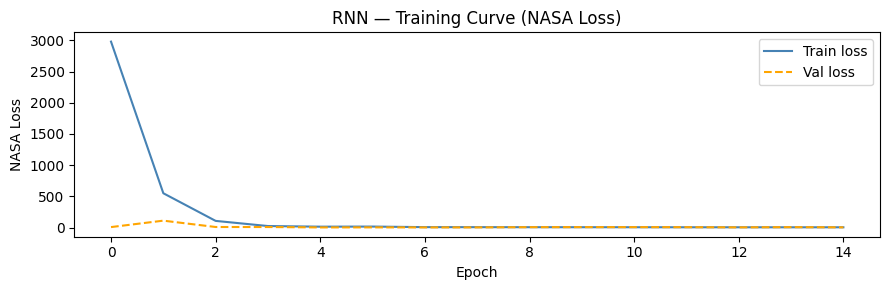

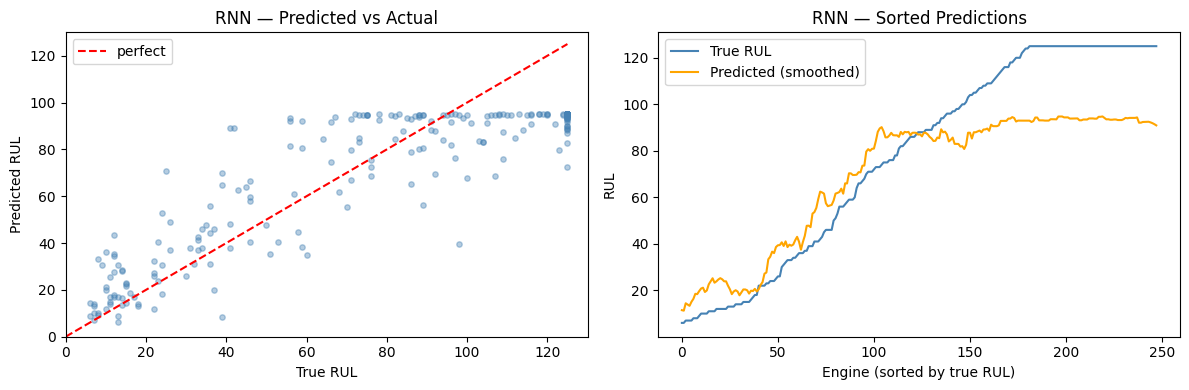

In [9]:
plot_loss_curves(train_losses, val_losses, model_name="RNN")
plot_predictions(y_true, y_pred, model_name="RNN")
